In [20]:
# 1. Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import warnings
warnings.filterwarnings("ignore")

In [21]:
# 2. Load dataset 
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 3. Display shape and first few rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [22]:
# 4. DATA OVERVIEW & VALIDATION

# Check info and missing values
df.info()
df.isna().sum()

# Check for unique values in categorical columns
for col in df.select_dtypes('object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Quick statistics for numeric columns
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
# 5. DATA CLEANING & PREPARATION

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many are NaN
print("Missing TotalCharges:", df['TotalCharges'].isna().sum())

# Drop rows with missing TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Drop customerID (unique identifier)
df.drop('customerID', axis=1, inplace=True)

# Convert target column
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Strip whitespace from object columns
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

print("Cleaned data shape:", df.shape)
df.head()


Missing TotalCharges: 11
Cleaned data shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


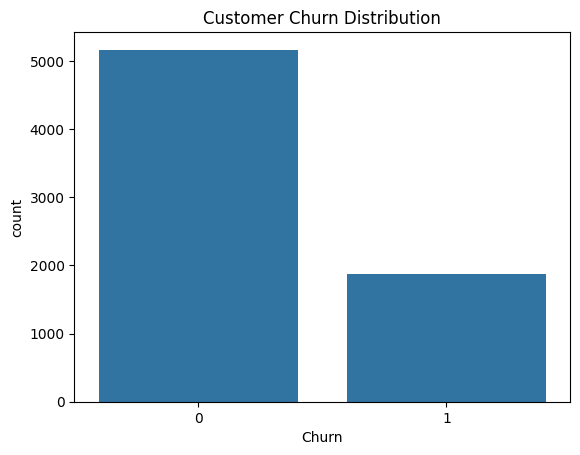

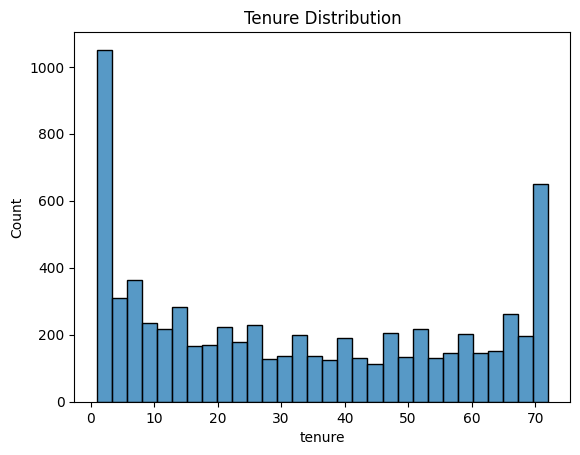

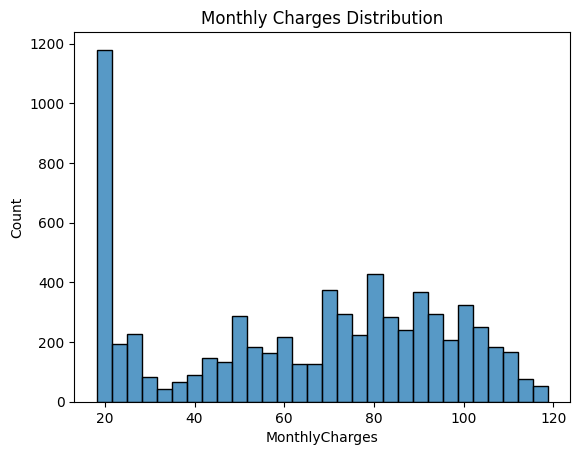

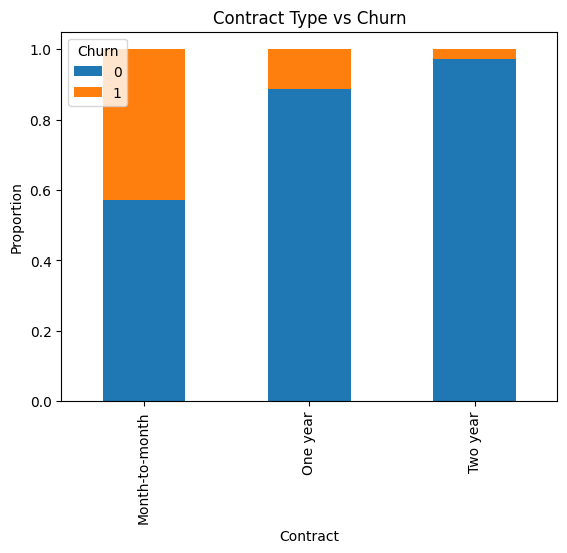

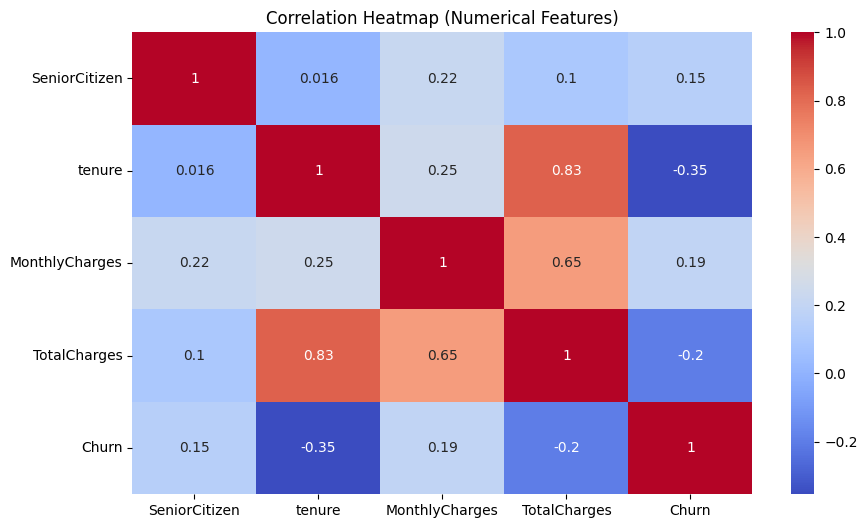

In [24]:
# 6. EXPLORATORY DATA ANALYSIS (EDA)

# Churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Tenure distribution
sns.histplot(df['tenure'], bins=30)
plt.title("Tenure Distribution")
plt.show()

# Monthly Charges distribution
sns.histplot(df['MonthlyCharges'], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

# Contract type vs Churn
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title("Contract Type vs Churn")
plt.ylabel("Proportion")
plt.show()

# Correlation heatmap
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


In [25]:
# 7. FEATURE ENGINEERING

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Standardize numeric columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (7032, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [26]:
# 8. MODEL DEVELOPMENT

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Baseline: Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

# Compare with Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


===== Logistic Regression =====
Accuracy: 0.8045486851457001
Precision: 0.649546827794562
Recall: 0.5748663101604278
F1 Score: 0.6099290780141844
ROC-AUC: 0.8360144638688001

Confusion Matrix:
 [[917 116]
 [159 215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



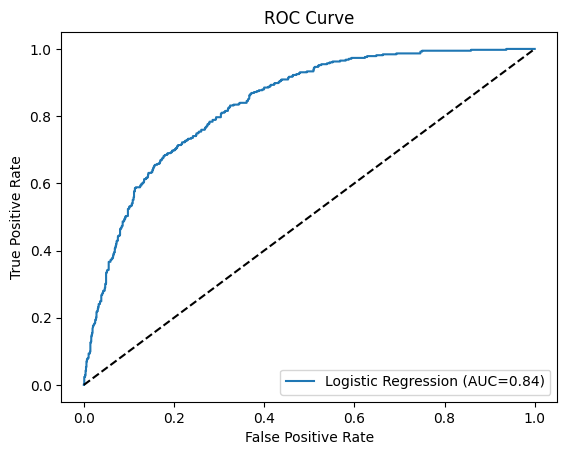

===== Random Forest =====
Accuracy: 0.7874911158493249
Precision: 0.6221498371335505
Recall: 0.5106951871657754
F1 Score: 0.5609397944199707
ROC-AUC: 0.8178453287501747

Confusion Matrix:
 [[917 116]
 [183 191]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



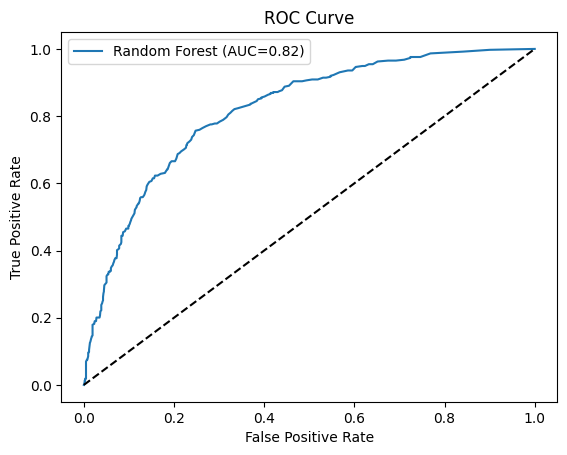

In [27]:
# 8. MODEL EVALUATION

def evaluate(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.2f})")
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

# Evaluate both models
evaluate(lr, X_test, y_test, "Logistic Regression")
evaluate(rf, X_test, y_test, "Random Forest")


Training Balanced Models...
Models trained successfully.

===== Logistic Regression (Balanced) =====
Best Threshold: 0.661
Precision: 0.588
Recall: 0.671
F1 Score: 0.627



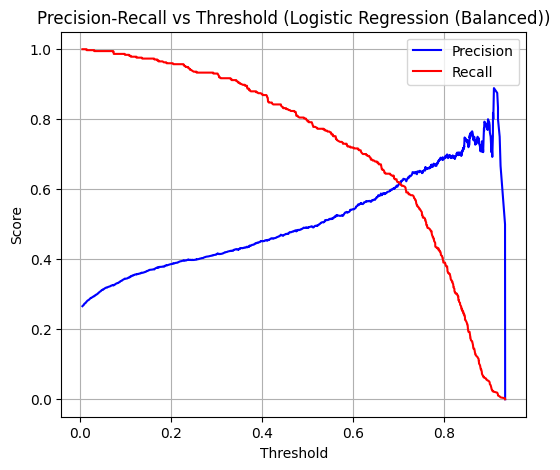

===== Random Forest (Balanced) =====
Best Threshold: 0.335
Precision: 0.538
Recall: 0.701
F1 Score: 0.609



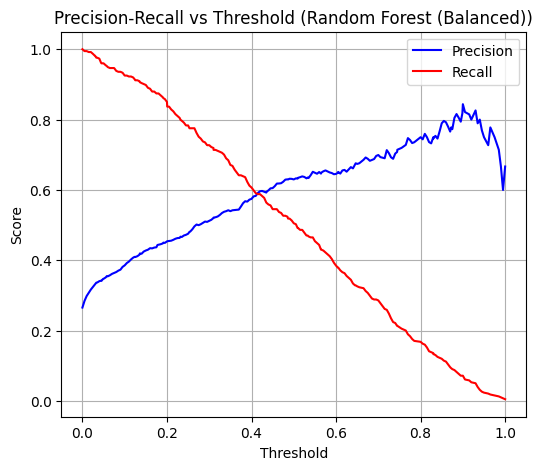

===== Logistic Regression (Optimized Threshold) =====
Accuracy: 0.787
Precision: 0.588
Recall: 0.671
F1 Score: 0.627
ROC-AUC: 0.835

Confusion Matrix:
[[857 176]
 [123 251]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.59      0.67      0.63       374

    accuracy                           0.79      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.79      0.79      1407



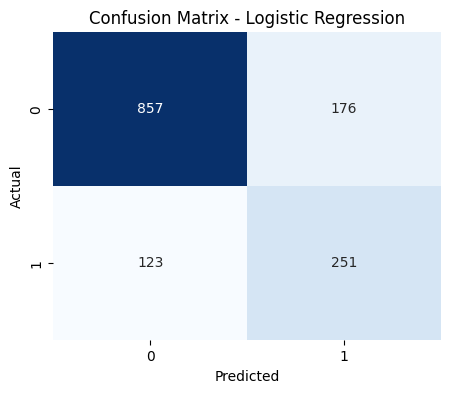

===== Random Forest (Optimized Threshold) =====
Accuracy: 0.760
Precision: 0.538
Recall: 0.701
F1 Score: 0.609
ROC-AUC: 0.819

Confusion Matrix:
[[808 225]
 [112 262]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1033
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.76      0.77      1407



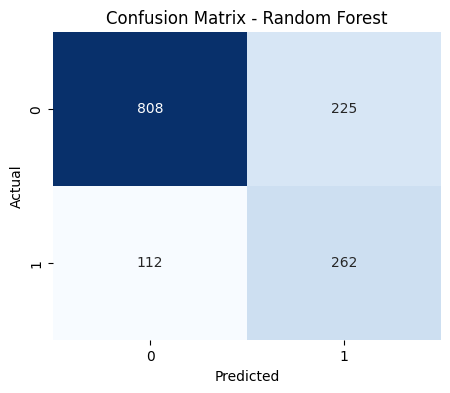

'\n# Logistic Regression Tuning\nparams_lr = {\n    \'C\': [0.01, 0.1, 1, 10],\n    \'penalty\': [\'l2\'],\n    \'solver\': [\'lbfgs\'],\n    \'class_weight\': [\'balanced\']\n}\n\ngrid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), params_lr, cv=5, scoring=\'f1\')\ngrid_lr.fit(X_train, y_train)\nprint("Best Logistic Regression Params:", grid_lr.best_params_)\n\n# Random Forest Tuning\nparams_rf = {\n    \'n_estimators\': [100, 200],\n    \'max_depth\': [5, 10, 20],\n    \'min_samples_split\': [2, 5, 10],\n    \'class_weight\': [\'balanced\']\n}\n\ngrid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params_rf, cv=3, scoring=\'f1\')\ngrid_rf.fit(X_train, y_train)\nprint("Best Random Forest Params:", grid_rf.best_params_)\n'

In [33]:

# 🧠 Model Optimization for Churn Prediction

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 1. Retrain Models with Balanced Class Weights

print("Training Balanced Models...")

lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf_balanced = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)

lr_balanced.fit(X_train, y_train)
rf_balanced.fit(X_train, y_train)

print("Models trained successfully.\n")



# 2. Find Optimal Threshold for Each Model

def optimal_threshold(model, X_test, y_test, model_name):
    """Find the optimal threshold that maximizes F1-score."""
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index]
    best_precision = precisions[best_index]
    best_recall = recalls[best_index]
    
    print(f"===== {model_name} =====")
    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"Precision: {best_precision:.3f}")
    print(f"Recall: {best_recall:.3f}")
    print(f"F1 Score: {f1_scores[best_index]:.3f}\n")

    # Plot Precision-Recall Curve
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
    plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
    plt.title(f'Precision-Recall vs Threshold ({model_name})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()
    plt.show()

    return best_threshold

lr_threshold = optimal_threshold(lr_balanced, X_test, y_test, "Logistic Regression (Balanced)")
rf_threshold = optimal_threshold(rf_balanced, X_test, y_test, "Random Forest (Balanced)")



# 3. Evaluate Models Using the Optimal Thresholds

def evaluate_model_threshold(model, X_test, y_test, threshold, model_name):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"===== {model_name} (Optimized Threshold) =====")
    print(f"Accuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"ROC-AUC: {auc:.3f}\n")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


evaluate_model_threshold(lr_balanced, X_test, y_test, lr_threshold, "Logistic Regression")
evaluate_model_threshold(rf_balanced, X_test, y_test, rf_threshold, "Random Forest")


# =====================================================
# 4️⃣ (Optional) Hyperparameter Tuning for Further Improvement
# =====================================================
# Uncomment to run

"""
# Logistic Regression Tuning
params_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), params_lr, cv=5, scoring='f1')
grid_lr.fit(X_train, y_train)
print("Best Logistic Regression Params:", grid_lr.best_params_)

# Random Forest Tuning
params_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params_rf, cv=3, scoring='f1')
grid_rf.fit(X_train, y_train)
print("Best Random Forest Params:", grid_rf.best_params_)
"""


Top 10 Features - Logistic Regression:

                       Feature  Coefficient
             Contract_Two year    -1.364197
                        tenure    -1.348550
   InternetService_Fiber optic     1.108470
             Contract_One year    -0.748888
                  TotalCharges     0.634001
              PhoneService_Yes    -0.517122
                MonthlyCharges    -0.430947
PaymentMethod_Electronic check     0.380924
            OnlineSecurity_Yes    -0.373453
               StreamingTV_Yes     0.371831


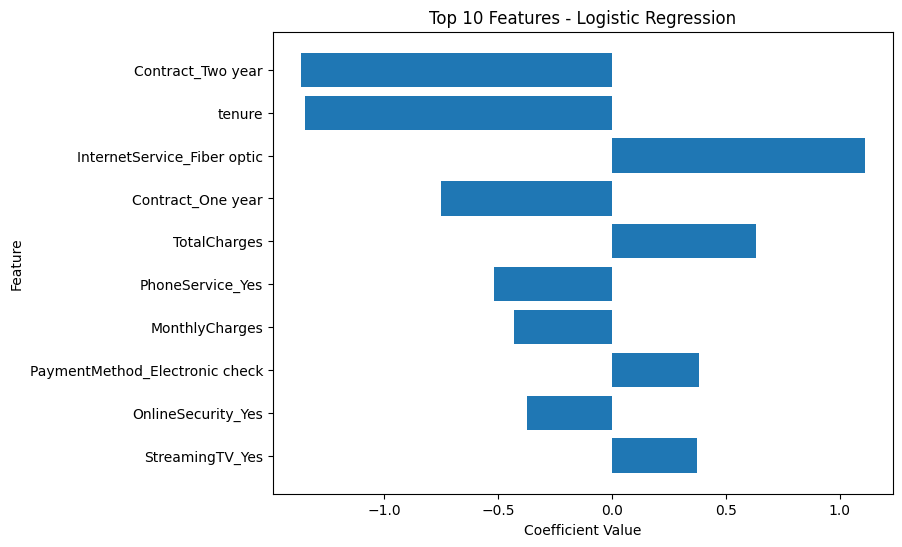

In [38]:
# 🔍 9. Feature Importance — Logistic Regression (Top 10 Clean Output)

# Create dataframe for coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

# Add absolute coefficient values for sorting
coefficients['Abs_Coefficient'] = np.abs(coefficients['Coefficient'])

# Sort by absolute value and select top 10
top10_lr = coefficients.sort_values('Abs_Coefficient', ascending=False).head(10).reset_index(drop=True)

# Display clean output
print("Top 10 Features - Logistic Regression:\n")
print(top10_lr[['Feature', 'Coefficient']].to_string(index=False))

# Plot the top 10 coefficients
plt.figure(figsize=(8,6))
plt.barh(top10_lr['Feature'], top10_lr['Coefficient'])
plt.title('Top 10 Features - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()


Top 10 Features - Random Forest:

                       Feature  Importance
                  TotalCharges    0.194313
                        tenure    0.168529
                MonthlyCharges    0.167972
   InternetService_Fiber optic    0.038913
PaymentMethod_Electronic check    0.037898
             Contract_Two year    0.031862
                   gender_Male    0.028939
            OnlineSecurity_Yes    0.027288
          PaperlessBilling_Yes    0.025595
                   Partner_Yes    0.023280


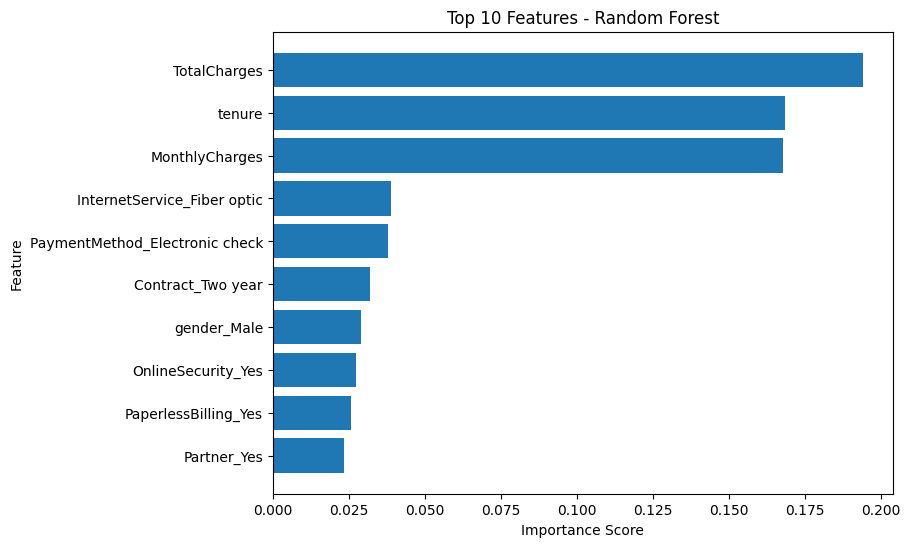

In [39]:
# 10. Feature Importance — Random Forest (Top 10)

# Calculate feature importance
importances = rf.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# Sort and select top 10
top10_rf = importance_df.sort_values('Importance', ascending=False).head(10)

# Reset index to remove numbering
top10_rf = top10_rf.reset_index(drop=True)

# Display clean table
print("Top 10 Features - Random Forest:\n")
print(top10_rf.to_string(index=False))

# Plot the top 10 features
plt.figure(figsize=(8,6))
plt.barh(top10_rf['Feature'], top10_rf['Importance'])
plt.title('Top 10 Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.show()
